In [4]:
import pandas as pd

BASE = r"C:\Users\Aleix\OneDrive - Universitat Politècnica de Catalunya\Escritorio\UNI\TFG\Recerca primers datasets\SicapV2\SICAPv2"

df = pd.read_excel(BASE + r"\partition\Validation\Val1\Train.xlsx")

print(df.shape)
print(df.columns.tolist())
print(df.head())

(7472, 6)
['image_name', 'NC', 'G3', 'G4', 'G5', 'G4C']
                                          image_name  NC  G3  G4  G5  G4C
0  16B0001851_Block_Region_1_0_0_xini_6803_yini_5...   0   0   0   1    0
1  16B0001851_Block_Region_1_0_1_xini_7827_yini_5...   0   0   0   1    0
2  16B0001851_Block_Region_1_0_2_xini_8851_yini_5...   0   0   0   1    0
3  16B0001851_Block_Region_1_0_3_xini_9875_yini_5...   0   0   0   1    0
4  16B0001851_Block_Region_1_1_0_xini_6803_yini_6...   0   0   0   1    0


In [5]:
df['patient_id'] = df['image_name'].str.split('_Block').str[0]

print("Pacients únics al train Val1:", df['patient_id'].nunique())
print(df['patient_id'].value_counts().head(10))

Pacients únics al train Val1: 95
patient_id
18B0005478J    339
18B0005478I    194
18B0005478G    186
18B0001510J    179
16B0022786     172
18B0005478E    172
18B0006621D    170
18B0005478F    169
18B0005478C    165
18B0005478H    157
Name: count, dtype: int64


In [6]:
# Convertim one-hot a etiqueta única
df['label'] = df[['NC', 'G3', 'G4', 'G5']].idxmax(axis=1)

print("Distribució de classes al train Val1:")
print(df['label'].value_counts())
print()
print("En percentatge:")
print(df['label'].value_counts(normalize=True).round(3) * 100)

Distribució de classes al train Val1:
label
NC    3088
G4    2662
G3    1204
G5     518
Name: count, dtype: int64

En percentatge:
label
NC    41.3
G4    35.6
G3    16.1
G5     6.9
Name: proportion, dtype: float64


In [8]:
resultats = []

for fold in ['Val1', 'Val2', 'Val3', 'Val4']:
    for split in ['Train', 'Test']:
        path = BASE + rf"\partition\Validation\{fold}\{split}.xlsx"
        df = pd.read_excel(path)
        df['label'] = df[['NC', 'G3', 'G4', 'G5']].idxmax(axis=1)
        df['patient_id'] = df['image_name'].str.split('_Block').str[0]
        
        counts = df['label'].value_counts()
        resultats.append({
            'fold': fold,
            'split': split,
            'n_patches': len(df),
            'n_pacients': df['patient_id'].nunique(),
            'NC%': round(counts.get('NC', 0) / len(df) * 100, 1),
            'G3%': round(counts.get('G3', 0) / len(df) * 100, 1),
            'G4%': round(counts.get('G4', 0) / len(df) * 100, 1),
            'G5%': round(counts.get('G5', 0) / len(df) * 100, 1),
        })

resum = pd.DataFrame(resultats)
print(resum.to_string(index=False))

fold split  n_patches  n_pacients  NC%  G3%  G4%  G5%
Val1 Train       7472          95 41.3 16.1 35.6  6.9
Val1  Test       2487          29 27.5 25.1 39.4  8.0
Val2 Train       7793          97 39.2 19.0 34.5  7.2
Val2  Test       2166          27 33.1 16.0 43.9  7.1
Val3 Train       8166          94 38.3 18.0 36.4  7.3
Val3  Test       1793          30 35.9 20.1 37.4  6.6
Val4 Train       6446          86 31.7 20.7 40.3  7.3
Val4  Test       3513          38 49.2 14.1 29.7  7.0


In [9]:
for fold in ['Val1', 'Val2', 'Val3', 'Val4']:
    train = pd.read_excel(BASE + rf"\partition\Validation\{fold}\Train.xlsx")
    test = pd.read_excel(BASE + rf"\partition\Validation\{fold}\Test.xlsx")
    
    train_pacients = set(train['image_name'].str.split('_Block').str[0])
    test_pacients = set(test['image_name'].str.split('_Block').str[0])
    
    solapament = train_pacients & test_pacients
    print(f"{fold}: {len(solapament)} pacients solapats")

Val1: 0 pacients solapats
Val2: 0 pacients solapats
Val3: 0 pacients solapats
Val4: 0 pacients solapats


In [10]:
for fold in ['Val1', 'Val2', 'Val3', 'Val4']:
    train = pd.read_excel(BASE + rf"\partition\Validation\{fold}\Train.xlsx")
    test = pd.read_excel(BASE + rf"\partition\Validation\{fold}\Test.xlsx")
    
    train_pacients = set(train['image_name'].str.split('_Block').str[0])
    test_pacients = set(test['image_name'].str.split('_Block').str[0])
    
    print(f"{fold}: train={len(train_pacients)} pacients, test={len(test_pacients)} pacients, total={len(train_pacients | test_pacients)}")

Val1: train=95 pacients, test=29 pacients, total=124
Val2: train=97 pacients, test=27 pacients, total=124
Val3: train=94 pacients, test=30 pacients, total=124
Val4: train=86 pacients, test=38 pacients, total=124


In [11]:
test_oficial = pd.read_excel(BASE + r"\partition\Test\Test.xlsx")
train_oficial = pd.read_excel(BASE + r"\partition\Test\Train.xlsx")

test_pacients = set(test_oficial['image_name'].str.split('_Block').str[0])
train_pacients = set(train_oficial['image_name'].str.split('_Block').str[0])

print(f"Test oficial: {len(test_pacients)} pacients")
print(f"Train oficial: {len(train_pacients)} pacients")
print(f"Total: {len(test_pacients | train_pacients)} pacients")

Test oficial: 31 pacients
Train oficial: 124 pacients
Total: 155 pacients


In [12]:
val_pacients = set()
for fold in ['Val1', 'Val2', 'Val3', 'Val4']:
    df_fold = pd.read_excel(BASE + rf"\partition\Validation\{fold}\Train.xlsx")
    val_pacients |= set(df_fold['image_name'].str.split('_Block').str[0])

test_oficial_pacients = set(test_oficial['image_name'].str.split('_Block').str[0])

solapament = val_pacients & test_oficial_pacients
print(f"Pacients solapats entre folds i test oficial: {len(solapament)}")

Pacients solapats entre folds i test oficial: 0


In [15]:
df

,image_name,NC,G3,G4,G5,G4C,label,patient_id
0,16B0006668_Block_Region_3_10_12_xini_66766_yin...,0,0,0,1,0,G5,16B0006668
1,16B0006668_Block_Region_3_10_13_xini_67790_yin...,0,0,0,1,0,G5,16B0006668
2,16B0006668_Block_Region_3_10_14_xini_68814_yin...,0,0,0,1,0,G5,16B0006668
3,16B0006668_Block_Region_3_10_15_xini_69838_yin...,0,0,0,1,0,G5,16B0006668
4,16B0006668_Block_Region_3_11_11_xini_65742_yin...,0,0,0,1,0,G5,16B0006668
...,...,...,...,...,...,...,...,...
3508,18B0005478J_Block_Region_1_9_25_xini_42445_yin...,1,0,0,0,0,NC,18B0005478J
3509,18B0005478J_Block_Region_1_9_26_xini_43469_yin...,1,0,0,0,0,NC,18B0005478J
3510,18B0005478J_Block_Region_1_9_27_xini_44493_yin...,1,0,0,0,0,NC,18B0005478J
3511,18B0005478J_Block_Region_1_9_28_xini_45517_yin...,1,0,0,0,0,NC,18B0005478J


In [16]:
nom_imatge

'16B0006668_Block_Region_3_10_12_xini_66766_yini_77884.jpg'

In [17]:
mask

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ..., 200, 200, 200],
       [  0,   0,   0, ..., 200, 200, 200],
       [  0,   0,   0, ..., 200, 200, 200]], shape=(512, 512), dtype=uint8)

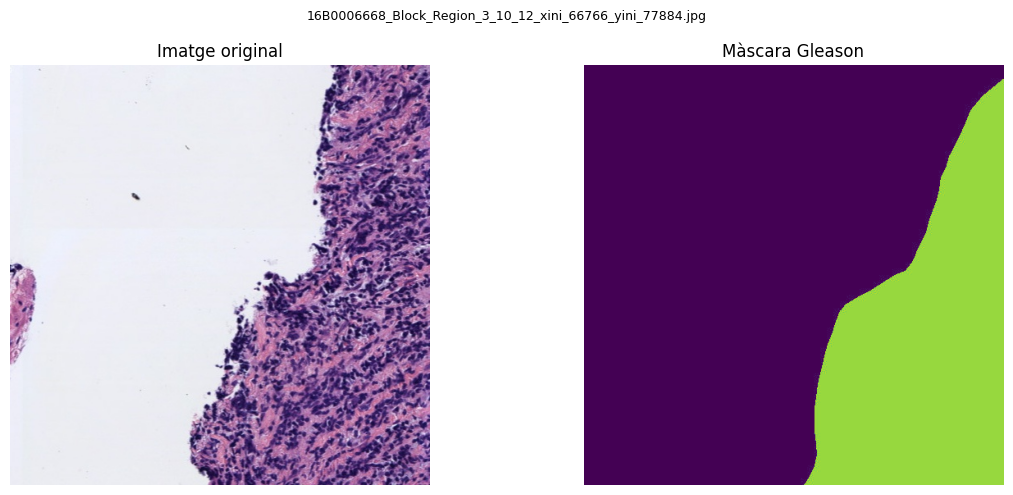

In [27]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Agafem el nom de la primera imatge del Val1 Train
nom_imatge = df['image_name'].iloc[0]

img  = mpimg.imread(BASE + r"\images\\" + nom_imatge)
mask = mpimg.imread(BASE + r"\masks\\"  + nom_imatge )

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title('Imatge original')
axes[0].axis('off')
axes[1].imshow(mask)
axes[1].set_title('Màscara Gleason')
axes[1].axis('off')

plt.suptitle(nom_imatge, fontsize=9)
plt.tight_layout()
plt.show()

In [28]:
import numpy as np

# Definim colors per classe: NC=verd, G3=groc, G4=taronja, G5=vermell
cmap = {0: [0, 255, 0], 1: [255, 255, 0], 2: [255, 165, 0], 3: [255, 0, 0]}

mask_raw = mpimg.imread(BASE + r"\masks\\" + nom_imatge)
print("Valors únics a la màscara:", np.unique(mask_raw))
print("Shape:", mask_raw.shape)

Valors únics a la màscara: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  32  34  36  40 160
 169 170 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187
 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205
 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223
 224 225 226 227 228 229 230 231 233 237]
Shape: (512, 512)


In [29]:
mask_rgb = mpimg.imread(BASE + r"\masks\\" + nom_imatge)
print("Shape:", mask_rgb.shape)
print("Dtype:", mask_rgb.dtype)

# Mirem els primers pixels
print("\nPrimers pixels:")
print(mask_rgb[:3, :3])

Shape: (512, 512)
Dtype: uint8

Primers píxels:
[[0 0 0]
 [0 0 0]
 [0 0 0]]


In [30]:
import cv2

mask_cv = cv2.imread(BASE + r"\masks\\" + nom_imatge, cv2.IMREAD_UNCHANGED)
print("Shape:", mask_cv.shape)
print("Dtype:", mask_cv.dtype)
print("Valors únics:", np.unique(mask_cv))
print("\nPrimers pixels:")
print(mask_cv[:3, :3])

AttributeError: 'NoneType' object has no attribute 'shape'

In [31]:
import os

ruta_mask = BASE + r"\masks\\" + nom_imatge
print("Ruta:", ruta_mask)
print("Existeix?", os.path.exists(ruta_mask))

# Llistem els primers fitxers de la carpeta masks
print("\nPrimers fitxers a masks:")
print(os.listdir(BASE + r"\masks")[:5])

Ruta: C:\Users\Aleix\OneDrive - Universitat Politècnica de Catalunya\Escritorio\UNI\TFG\Recerca primers datasets\SicapV2\SICAPv2\masks\\16B0006668_Block_Region_3_10_12_xini_66766_yini_77884.jpg
Existeix? True

Primers fitxers a masks:
['16B0001851_Block_Region_1_0_0_xini_6803_yini_59786.jpg', '16B0001851_Block_Region_1_0_1_xini_7827_yini_59786.jpg', '16B0001851_Block_Region_1_0_2_xini_8851_yini_59786.jpg', '16B0001851_Block_Region_1_0_3_xini_9875_yini_59786.jpg', '16B0001851_Block_Region_1_1_0_xini_6803_yini_60810.jpg']


In [32]:
from PIL import Image

mask_pil = Image.open(ruta_mask)
print("Mode:", mask_pil.mode)
print("Size:", mask_pil.size)

mask_arr = np.array(mask_pil)
print("Shape:", mask_arr.shape)
print("Dtype:", mask_arr.dtype)
print("Valors únics:", np.unique(mask_arr))
print("\nPrimers pixels:")
print(mask_arr[:3, :3])

Mode: L
Size: (512, 512)
Shape: (512, 512)
Dtype: uint8
Valors únics: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  32  34  36  40 160
 169 170 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187
 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205
 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223
 224 225 226 227 228 229 230 231 233 237]

Primers píxels:
[[0 0 0]
 [0 0 0]
 [0 0 0]]


In [36]:
import os
import numpy as np
from PIL import Image

BASE = r"C:\Users\Aleix\OneDrive - Universitat Politècnica de Catalunya\Escritorio\UNI\TFG\Recerca primers datasets\SicapV2\SICAPv2"
mask_dir = os.path.join(BASE, "masks")

valors = set()
for fname in os.listdir(mask_dir):
    if not fname.lower().endswith((".png", ".tif", ".jpg")):
        continue
    arr = np.array(Image.open(os.path.join(mask_dir, fname)))
    valors.update(np.unique(arr).tolist())
    
print("valors únics trobats a totes les màscares:", sorted(valors))

valors únics trobats a totes les màscares: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 2

In [37]:
for fold in ['Val1', 'Val2', 'Val3', 'Val4']:
    train = pd.read_excel(BASE + rf"\partition\Validation\{fold}\Train.xlsx")
    test = pd.read_excel(BASE + rf"\partition\Validation\{fold}\Test.xlsx")
    
    train_p = train['image_name'].str.split('_Block').str[0].nunique()
    test_p = test['image_name'].str.split('_Block').str[0].nunique()
    
    print(f"{fold}: {train_p} train + {test_p} test = {train_p + test_p} pacients")

Val1: 95 train + 29 test = 124 pacients
Val2: 97 train + 27 test = 124 pacients
Val3: 94 train + 30 test = 124 pacients
Val4: 86 train + 38 test = 124 pacients


In [44]:
wsi = pd.read_excel(BASE + r"\wsi_labels.xlsx")
print(wsi.columns.tolist())
print(wsi.head(10))

['slide_id', 'patient_id', 'Gleason_primary', 'Gleason_secondary']
     slide_id  patient_id  Gleason_primary  Gleason_secondary
0  16B0001851      667360                4                  5
1  16B0003388      325687                4                  4
2  16B0003394      747184                3                  3
3  16B0006668       14107                5                  5
4  16B0006669       14107                5                  5
5  16B0006694      711210                4                  5
6  16B0006695      711210                4                  5
7  16B0008045      747731                3                  3
8  16B0008067      425843                4                  5
9  16B0022608      296752                4                  3


In [45]:
biopsies_per_pacient = wsi.groupby('patient_id')['slide_id'].count().sort_values(ascending=False)
print("Distribució de biòpsies per pacient:")
print(biopsies_per_pacient.value_counts().sort_index())
print("\nPacients amb més biòpsies:")
print(biopsies_per_pacient.head(10))

Distribució de biòpsies per pacient:
slide_id
1     68
2     17
3      3
4      2
5      1
6      2
9      1
10     1
Name: count, dtype: int64

Pacients amb més biòpsies:
patient_id
173061    10
778712     9
296752     6
708946     6
471646     5
594051     4
757015     4
753669     3
474321     3
122718     3
Name: slide_id, dtype: int64


In [46]:
dfs = []

# Folds de validació creuada
for fold in ['Val1', 'Val2', 'Val3', 'Val4']:
    for split in ['Train', 'Test']:
        df_tmp = pd.read_excel(BASE + rf"\partition\Validation\{fold}\{split}.xlsx")
        df_tmp['fold'] = fold
        df_tmp['split'] = split
        dfs.append(df_tmp)

# Test oficial
for split in ['Train', 'Test']:
    df_tmp = pd.read_excel(BASE + rf"\partition\Test\{split}.xlsx")
    df_tmp['fold'] = 'Test_oficial'
    df_tmp['split'] = split
    dfs.append(df_tmp)

# Unim tot
df_all = pd.concat(dfs, ignore_index=True)

# Afegim columnes útils
df_all['patient_id'] = df_all['image_name'].str.split('_Block').str[0]
df_all['label'] = df_all[['NC', 'G3', 'G4', 'G5']].idxmax(axis=1)

print("Shape total:", df_all.shape)
print("Columnes:", df_all.columns.tolist())
print(df_all.head(3))

Shape total: (51917, 10)
Columnes: ['image_name', 'NC', 'G3', 'G4', 'G5', 'G4C', 'fold', 'split', 'patient_id', 'label']
                                          image_name  NC  G3  G4  G5  G4C  \
0  16B0001851_Block_Region_1_0_0_xini_6803_yini_5...   0   0   0   1    0   
1  16B0001851_Block_Region_1_0_1_xini_7827_yini_5...   0   0   0   1    0   
2  16B0001851_Block_Region_1_0_2_xini_8851_yini_5...   0   0   0   1    0   

   fold  split  patient_id label  
0  Val1  Train  16B0001851    G5  
1  Val1  Train  16B0001851    G5  
2  Val1  Train  16B0001851    G5  


In [47]:
for fold in ['Val1', 'Val2', 'Val3', 'Val4']:
    df_fold = df_all[df_all['fold'] == fold]
    train = df_fold[df_fold['split'] == 'Train']
    test = df_fold[df_fold['split'] == 'Test']
    
    print(f"\n--- {fold} ---")
    print(f"Train: {train['patient_id'].nunique()} pacients, {len(train)} patches")
    print(f"Test:  {test['patient_id'].nunique()} pacients, {len(test)} patches")
    print(f"Train classes: NC={round(train['NC'].sum()/len(train)*100,1)}% G3={round(train['G3'].sum()/len(train)*100,1)}% G4={round(train['G4'].sum()/len(train)*100,1)}% G5={round(train['G5'].sum()/len(train)*100,1)}%")
    print(f"Test  classes: NC={round(test['NC'].sum()/len(test)*100,1)}% G3={round(test['G3'].sum()/len(test)*100,1)}% G4={round(test['G4'].sum()/len(test)*100,1)}% G5={round(test['G5'].sum()/len(test)*100,1)}%")


--- Val1 ---
Train: 95 pacients, 7472 patches
Test:  29 pacients, 2487 patches
Train classes: NC=41.3% G3=16.1% G4=35.6% G5=6.9%
Test  classes: NC=27.5% G3=25.1% G4=39.4% G5=8.0%

--- Val2 ---
Train: 97 pacients, 7793 patches
Test:  27 pacients, 2166 patches
Train classes: NC=39.2% G3=19.0% G4=34.5% G5=7.2%
Test  classes: NC=33.1% G3=16.0% G4=43.9% G5=7.1%

--- Val3 ---
Train: 94 pacients, 8166 patches
Test:  30 pacients, 1793 patches
Train classes: NC=38.3% G3=18.0% G4=36.4% G5=7.3%
Test  classes: NC=35.9% G3=20.1% G4=37.4% G5=6.6%

--- Val4 ---
Train: 86 pacients, 6446 patches
Test:  38 pacients, 3513 patches
Train classes: NC=31.7% G3=20.7% G4=40.3% G5=7.3%
Test  classes: NC=49.2% G3=14.1% G4=29.7% G5=7.0%


In [48]:
print(wsi.columns.tolist())
print(wsi.head(10))

['slide_id', 'patient_id', 'Gleason_primary', 'Gleason_secondary']
     slide_id  patient_id  Gleason_primary  Gleason_secondary
0  16B0001851      667360                4                  5
1  16B0003388      325687                4                  4
2  16B0003394      747184                3                  3
3  16B0006668       14107                5                  5
4  16B0006669       14107                5                  5
5  16B0006694      711210                4                  5
6  16B0006695      711210                4                  5
7  16B0008045      747731                3                  3
8  16B0008067      425843                4                  5
9  16B0022608      296752                4                  3


In [57]:
import os
import pandas as pd

BASE = r"C:\Users\Aleix\OneDrive - Universitat Politècnica de Catalunya\Escritorio\UNI\TFG\Recerca primers datasets\SicapV2\SICAPv2"

# carregar el mapeig slide→patient
wsi = pd.read_excel(os.path.join(BASE, "wsi_labels.xlsx"))

# construir el df global com abans
dfs = []
for fold in ['Val1', 'Val2', 'Val3', 'Val4']:
    for split in ['Train', 'Test']:
        df_tmp = pd.read_excel(os.path.join(BASE, "partition", "Validation", fold, f"{split}.xlsx"))
        df_tmp['fold'] = fold
        df_tmp['split'] = split
        dfs.append(df_tmp)
for split in ['Train', 'Test']:
    df_tmp = pd.read_excel(os.path.join(BASE, "partition", "Test", f"{split}.xlsx"))
    df_tmp['fold'] = 'Test_oficial'
    df_tmp['split'] = split
    dfs.append(df_tmp)

df_all = pd.concat(dfs, ignore_index=True)

# extreure slide_id i merge amb wsi_labels per obtenir el veritable patient_id
df_all['slide_id'] = df_all['image_name'].str.split('_Block').str[0]
df_all = df_all.merge(wsi[['slide_id', 'patient_id']], on='slide_id', how='left')

# comprovar que no hi hagi valors perduts
if df_all['patient_id'].isna().any():
    print("!! imatges sense pacient en wsi_labels:", df_all.loc[df_all['patient_id'].isna(), 'slide_id'].unique())

# etiqueta única
df_all['label'] = df_all[['NC', 'G3', 'G4', 'G5']].idxmax(axis=1)

# nombre de pacients reals
unique_patients = df_all['patient_id'].nunique()
print("Pacients únics en tot el dataset:", unique_patients)
assert unique_patients == 95, "no coincideixen els 95 pacients esperats"

# resum per fold/split
for fold in ['Val1', 'Val2', 'Val3', 'Val4']:
    df_fold = df_all[df_all['fold'] == fold]
    train = df_fold[df_fold['split'] == 'Train']
    test  = df_fold[df_fold['split'] == 'Test']

    pts_train = set(train['patient_id'])
    pts_test  = set(test['patient_id'])
    pts_fold  = pts_train | pts_test

    print(f"\n--- {fold} ---")
    print(f"pacients: train={len(pts_train)}  test={len(pts_test)}  total={len(pts_fold)}")
    print(f"patches:  train={len(train):6d}  test={len(test):6d}")
    for cl in ['NC','G3','G4','G5']:
        pct_train = round(train[cl].sum()/len(train)*100,1)
        pct_test  = round(test[cl].sum()/len(test)*100,1)
        print(f"    {cl}: train={pct_train:4.1f}%  test={pct_test:4.1f}%")

# optional: taula resumida
summary = []
for fold in ['Val1','Val2','Val3','Val4']:
    df_fold = df_all[df_all['fold'] == fold]
    for split in ['Train','Test']:
        df_s = df_fold[df_fold['split'] == split]
        pts = set(df_s['patient_id'])
        summary.append({
            'fold': fold, 'split': split,
            'n_patches': len(df_s),
            'n_patients': len(pts),
            'NC%': round(df_s['NC'].sum()/len(df_s)*100,1),
            'G3%': round(df_s['G3'].sum()/len(df_s)*100,1),
            'G4%': round(df_s['G4'].sum()/len(df_s)*100,1),
            'G5%': round(df_s['G5'].sum()/len(df_s)*100,1),
        })
summary_df = pd.DataFrame(summary)
print("\nResum en taula:")
print(summary_df)

# verificació extra: la unió dels quatre folds
unio_folds = set()
for fold in ['Val1','Val2','Val3','Val4']:
    df_fold = df_all[df_all['fold']==fold]
    unio_folds |= set(df_fold['patient_id'])
print("\nPacients únics en els quatre folds:", len(unio_folds))  # 95 també

Pacients únics en tot el dataset: 95

--- Val1 ---
pacients: train=56  test=18  total=74
patches:  train=  7472  test=  2487
    NC: train=41.3%  test=27.5%
    G3: train=16.1%  test=25.1%
    G4: train=35.6%  test=39.4%
    G5: train= 6.9%  test= 8.0%

--- Val2 ---
pacients: train=57  test=17  total=74
patches:  train=  7793  test=  2166
    NC: train=39.2%  test=33.1%
    G3: train=19.0%  test=16.0%
    G4: train=34.5%  test=43.9%
    G5: train= 7.2%  test= 7.1%

--- Val3 ---
pacients: train=55  test=19  total=74
patches:  train=  8166  test=  1793
    NC: train=38.3%  test=35.9%
    G3: train=18.0%  test=20.1%
    G4: train=36.4%  test=37.4%
    G5: train= 7.3%  test= 6.6%

--- Val4 ---
pacients: train=54  test=20  total=74
patches:  train=  6446  test=  3513
    NC: train=31.7%  test=49.2%
    G3: train=20.7%  test=14.1%
    G4: train=40.3%  test=29.7%
    G5: train= 7.3%  test= 7.0%

Resum en taula:
   fold  split  n_patches  n_patients   NC%   G3%   G4%  G5%
0  Val1  Train       

In [59]:
test_of = df_all[df_all['fold'] == 'Test_oficial']
train_of = test_of[test_of['split'] == 'Train']
test_of_test = test_of[test_of['split'] == 'Test']

print(f"Test oficial train: {train_of['patient_id'].nunique()} pacients, {train_of['slide_id'].nunique()} WSIs, {len(train_of)} patches")
print(f"Test oficial test:  {test_of_test['patient_id'].nunique()} pacients, {test_of_test['slide_id'].nunique()} WSIs, {len(test_of_test)} patches")

Test oficial train: 74 pacients, 124 WSIs, 9959 patches
Test oficial test:  21 pacients, 31 WSIs, 2122 patches


In [60]:
df_all

,image_name,NC,G3,G4,G5,G4C,fold,split,slide_id,patient_id,label
0,16B0001851_Block_Region_1_0_0_xini_6803_yini_5...,0,0,0,1,0,Val1,Train,16B0001851,667360,G5
1,16B0001851_Block_Region_1_0_1_xini_7827_yini_5...,0,0,0,1,0,Val1,Train,16B0001851,667360,G5
2,16B0001851_Block_Region_1_0_2_xini_8851_yini_5...,0,0,0,1,0,Val1,Train,16B0001851,667360,G5
3,16B0001851_Block_Region_1_0_3_xini_9875_yini_5...,0,0,0,1,0,Val1,Train,16B0001851,667360,G5
4,16B0001851_Block_Region_1_1_0_xini_6803_yini_6...,0,0,0,1,0,Val1,Train,16B0001851,667360,G5
...,...,...,...,...,...,...,...,...,...,...,...
51912,16B0028168_Block_Region_5_8_18_xini_37750_yini...,1,0,0,0,0,Test_oficial,Test,16B0028168,512372,NC
51913,16B0028168_Block_Region_5_8_19_xini_38774_yini...,1,0,0,0,0,Test_oficial,Test,16B0028168,512372,NC
51914,16B0028168_Block_Region_5_9_17_xini_36726_yini...,1,0,0,0,0,Test_oficial,Test,16B0028168,512372,NC
51915,16B0028168_Block_Region_5_9_18_xini_37750_yini...,1,0,0,0,0,Test_oficial,Test,16B0028168,512372,NC


In [61]:
print("Total files df_all:", len(df_all))
print("Patches únics:", df_all['image_name'].nunique())
print("Mitjana d'aparicions per patch:", round(len(df_all) / df_all['image_name'].nunique(), 1))

Total files df_all: 51917
Patches únics: 12081
Mitjana d'aparicions per patch: 4.3


In [64]:
print(f"Nombre total d'imatges: {df_all['image_name'].nunique()}")

Nombre total d'imatges: 12081


In [63]:
import os

images_dir = os.path.join(BASE, "images")
num_images = len(os.listdir(images_dir))
print(f"Nombre total d'imatges a la carpeta: {num_images}")

Nombre total d'imatges a la carpeta: 18783


In [65]:
import os

# obtenir les imatges de la carpeta
images_dir = os.path.join(BASE, "images")
images_carpeta = set(os.listdir(images_dir))

# obtenir les imatges de df_all
images_df = set(df_all['image_name'].unique())

# imatges que estan a la carpeta però NO a df_all
imatges_no_referenciades = images_carpeta - images_df
print(f"Imatges a la carpeta però NO a df_all: {len(imatges_no_referenciades)}")

# imatges que estan a df_all però NO a la carpeta (això no hauria de passar)
imatges_mancants = images_df - images_carpeta
print(f"Imatges a df_all però NO a la carpeta: {len(imatges_mancants)}")

# per veure els primers exemples de les que falten
if imatges_no_referenciades:
    print(f"\nExemples d'imatges no referenciades:")
    for img in list(imatges_no_referenciades)[:10]:
        print(f"  {img}")

Imatges a la carpeta però NO a df_all: 6702
Imatges a df_all però NO a la carpeta: 0

Exemples d'imatges no referenciades:
  16B0028914_Block_Region_1_16_12_xini_37239_yini_111621.jpg
  17B0032153_Block_Region_10_28_32_xini_38465_yini_31047.jpg
  17B0016583_Block_Region_3_31_1_xini_29170_yini_115661.jpg
  16B0006668_Block_Region_3_3_16_xini_70862_yini_70716.jpg
  18B0003032A_Block_Region_2_1_5_xini_11259_yini_2408.jpg
  17B0024636_Block_Region_20_1_1_xini_7050_yini_36373.jpg
  16B0022610_Block_Region_9_9_5_xini_16438_yini_15174.jpg
  16B0008067_Block_Region_0_16_15_xini_24171_yini_113353.jpg
  17B0023909_Block_Region_5_20_8_xini_13024_yini_26438.jpg
  17B0016589_Block_Region_0_27_28_xini_34596_yini_108702.jpg


In [67]:
# Totes les imatges que hi ha al disc
imatges_disc = set([f for f in os.listdir(BASE + r"\images")])

# Totes les imatges que surten als folds
imatges_folds = set(df_all['image_name'].unique())

# Les que estan al disc però no als folds
nomes_disc = imatges_disc - imatges_folds

# Les que estan als folds però no al disc (no hauria d'haver-n'hi)
nomes_folds = imatges_folds - imatges_disc

print(f"Imatges al disc:        {len(imatges_disc)}")
print(f"Imatges als folds:      {len(imatges_folds)}")
print(f"Només al disc:          {len(nomes_disc)}")
print(f"Només als folds:        {len(nomes_folds)}")

# De quins pacients són les que falten?
nomes_disc_df = pd.DataFrame({'image_name': list(nomes_disc)})
nomes_disc_df['slide_id'] = nomes_disc_df['image_name'].str.split('_Block').str[0]
print(f"\nWSIs amb imatges no assignades a cap fold: {nomes_disc_df['slide_id'].nunique()}")

Imatges al disc:        18783
Imatges als folds:      12081
Només al disc:          6702
Només als folds:        0

WSIs amb imatges no assignades a cap fold: 117


In [68]:
# WSIs que apareixen als folds
wsis_folds = set(df_all['slide_id'].unique())

# WSIs de les imatges no assignades
wsis_nomes_disc = set(nomes_disc_df['slide_id'].unique())

# Quantes d'aquestes WSIs apareixen als folds?
wsis_compartides = wsis_folds & wsis_nomes_disc
wsis_noves = wsis_nomes_disc - wsis_folds

print(f"WSIs no assignades que SÍ apareixen als folds: {len(wsis_compartides)}")
print(f"WSIs no assignades que NO apareixen als folds:  {len(wsis_noves)}")
print(f"\nExemple de WSIs noves (no als folds):")
print(list(wsis_noves)[:10])

WSIs no assignades que SÍ apareixen als folds: 117
WSIs no assignades que NO apareixen als folds:  0

Exemple de WSIs noves (no als folds):
[]


In [69]:
# Patches per WSI al disc
patches_disc = nomes_disc_df.groupby('slide_id').size().reset_index(name='patches_disc')

# Patches per WSI als folds (només únics)
patches_folds = df_all.drop_duplicates('image_name').groupby('slide_id').size().reset_index(name='patches_folds')

# Unim
comparacio = patches_disc.merge(patches_folds, on='slide_id', how='outer').fillna(0)
comparacio['total'] = comparacio['patches_disc'] + comparacio['patches_folds']
comparacio = comparacio.sort_values('patches_disc', ascending=False)

print(comparacio.head(15))
print(f"\nTotal patches no assignats: {int(comparacio['patches_disc'].sum())}")
print(f"Total patches assignats:    {int(comparacio['patches_folds'].sum())}")

        slide_id  patches_disc  patches_folds  total
41    16B0028914         205.0            126  331.0
24    16B0026792         189.0             92  281.0
21    16B0024175         174.0             13  187.0
56    17B0018428         174.0             13  187.0
100  18B0001966H         156.0             30  186.0
25    16B0026794         148.0             37  185.0
110  18B0003894H         139.0             25  164.0
18    16B0023614         136.0             44  180.0
69    17B0028627         130.0             95  225.0
47    17B0015969         129.0             54  183.0
48    17B0016566         109.0             74  183.0
93    17B0035220         106.0             34  140.0
17    16B0023613         106.0             47  153.0
6     16B0006695         105.0             60  165.0
97   18B0001506G         105.0             54  159.0

Total patches no assignats: 6702
Total patches assignats:    12081


In [70]:
# Carreguem els labels de les imatges assignades
labels_assignats = df_all.drop_duplicates('image_name')[['image_name', 'label']]

# Per les no assignades no tenim labels als Excel...
# Però podem mirar si hi ha un patró en quines WSIs tenen més patches no assignats
comparacio_wsi = comparacio.merge(
    wsi[['slide_id', 'patient_id', 'Gleason_primary', 'Gleason_secondary']], 
    on='slide_id', how='left'
)

print("Gleason primari de les WSIs amb més patches no assignats:")
print(comparacio_wsi[['slide_id', 'patches_disc', 'patches_folds', 'Gleason_primary']].head(15))
print("\nDistribució Gleason primari (WSIs amb patches no assignats):")
print(comparacio_wsi['Gleason_primary'].value_counts())

Gleason primari de les WSIs amb més patches no assignats:
       slide_id  patches_disc  patches_folds  Gleason_primary
0    16B0028914         205.0            126                3
1    16B0026792         189.0             92                5
2    16B0024175         174.0             13                3
3    17B0018428         174.0             13                3
4   18B0001966H         156.0             30                4
5    16B0026794         148.0             37                5
6   18B0003894H         139.0             25                3
7    16B0023614         136.0             44                4
8    17B0028627         130.0             95                5
9    17B0015969         129.0             54                4
10   17B0016566         109.0             74                4
11   17B0035220         106.0             34                3
12   16B0023613         106.0             47                4
13   16B0006695         105.0             60                4
14  18B00015

In [71]:
# WSIs benignes (Gleason_primary = 0)
wsis_benignes = wsi[wsi['Gleason_primary'] == 0]['slide_id'].tolist()

print(f"Total WSIs benignes: {len(wsis_benignes)}")

# Quantes d'elles tenen patches als folds?
wsis_benignes_folds = df_all[df_all['slide_id'].isin(wsis_benignes)]['slide_id'].nunique()
wsis_benignes_disc = nomes_disc_df[nomes_disc_df['slide_id'].isin(wsis_benignes)]['slide_id'].nunique()

print(f"WSIs benignes amb patches als folds: {wsis_benignes_folds}")
print(f"WSIs benignes amb patches NOMÉS al disc: {wsis_benignes_disc}")

Total WSIs benignes: 36
WSIs benignes amb patches als folds: 36
WSIs benignes amb patches NOMÉS al disc: 0


In [74]:
# Patches al disc per totes les WSIs
patches_disc_totes = pd.DataFrame({
    'image_name': list(imatges_disc)
})
patches_disc_totes['slide_id'] = patches_disc_totes['image_name'].str.split('_Block').str[0]
patches_disc_totes = patches_disc_totes.groupby('slide_id').size().reset_index(name='patches_disc')

# Patches als folds per totes les WSIs
patches_folds_totes = df_all.drop_duplicates('image_name').groupby('slide_id').size().reset_index(name='patches_folds')

# Unim amb wsi_labels
comparacio_completa = patches_disc_totes.merge(patches_folds_totes, on='slide_id', how='outer').fillna(0)
comparacio_completa = comparacio_completa.merge(wsi[['slide_id', 'Gleason_primary']], on='slide_id', how='left')
comparacio_completa['tipus'] = comparacio_completa['Gleason_primary'].apply(
    lambda x: 'Benigne (NC)' if x == 0 else 'Cancerós'
)

resum_correcte2 = comparacio_completa.groupby('tipus').agg(
    n_wsis=('slide_id', 'count'),
    patches_disc=('patches_disc', 'sum'),
    patches_folds=('patches_folds', 'sum'),
)
resum_correcte2['total_patches'] = resum_correcte2['patches_disc'] + resum_correcte2['patches_folds']
resum_correcte2['pct_seleccionat'] = round(resum_correcte2['patches_folds'] / resum_correcte2['total_patches'] * 100, 1)

print(resum_correcte2)
print(f"\nTotal patches al disc:   {int(resum_correcte2['total_patches'].sum())}")
print(f"Total patches als folds: {int(resum_correcte2['patches_folds'].sum())}")

              n_wsis  patches_disc  patches_folds  total_patches  \
tipus                                                              
Benigne (NC)      36          4417           4417           8834   
Cancerós         119         14366           7664          22030   

              pct_seleccionat  
tipus                          
Benigne (NC)             50.0  
Cancerós                 34.8  

Total patches al disc:   30864
Total patches als folds: 12081


In [75]:
# patches_disc ja inclou TOTES les imatges del disc (assignades i no assignades)
# patches_folds és un subconjunt de patches_disc

resum_correcte3 = comparacio_completa.groupby('tipus').agg(
    n_wsis=('slide_id', 'count'),
    total_disc=('patches_disc', 'sum'),
    als_folds=('patches_folds', 'sum'),
)

resum_correcte3['no_assignats'] = resum_correcte3['total_disc'] - resum_correcte3['als_folds']
resum_correcte3['pct_seleccionat'] = round(resum_correcte3['als_folds'] / resum_correcte3['total_disc'] * 100, 1)

print(resum_correcte3)
print(f"\nTotal patches al disc:        {int(resum_correcte3['total_disc'].sum())}")
print(f"Total patches als folds:      {int(resum_correcte3['als_folds'].sum())}")
print(f"Total patches no assignats:   {int(resum_correcte3['no_assignats'].sum())}")

              n_wsis  total_disc  als_folds  no_assignats  pct_seleccionat
tipus                                                                     
Benigne (NC)      36        4417       4417             0            100.0
Cancerós         119       14366       7664          6702             53.3

Total patches al disc:        18783
Total patches als folds:      12081
Total patches no assignats:   6702


In [76]:
import os

# obtenir les imatges de la carpeta
images_dir = os.path.join(BASE, "images")
images_carpeta = set(os.listdir(images_dir))

# obtenir les imatges de df_all
images_df = set(df_all['image_name'].unique())

# imatges que estan a la carpeta però NO a df_all
imatges_no_referenciades = images_carpeta - images_df

print(f"Total imatges no referenciades: {len(imatges_no_referenciades)}")

# comprovar si alguna està al test oficial
test_oficial = df_all[df_all['fold'] == 'Test_oficial']
images_test_oficial = set(test_oficial['image_name'].unique())

imatges_no_ref_al_test = imatges_no_referenciades & images_test_oficial
imatges_no_ref_fora_test = imatges_no_referenciades - images_test_oficial

print(f"Imatges no referenciades que SÍ estan al test oficial: {len(imatges_no_ref_al_test)}")
print(f"Imatges no referenciades que NO estan a df_all en total: {len(imatges_no_ref_fora_test)}")

# exemplos de les que no estan
if imatges_no_ref_fora_test:
    print(f"\nExemples d'imatges que no estan a cap partició:")
    for img in list(imatges_no_ref_fora_test)[:10]:
        print(f"  {img}")

Total imatges no referenciades: 6702
Imatges no referenciades que SÍ estan al test oficial: 0
Imatges no referenciades que NO estan a df_all en total: 6702

Exemples d'imatges que no estan a cap partició:
  16B0028914_Block_Region_1_16_12_xini_37239_yini_111621.jpg
  17B0032153_Block_Region_10_28_32_xini_38465_yini_31047.jpg
  17B0016583_Block_Region_3_31_1_xini_29170_yini_115661.jpg
  16B0006668_Block_Region_3_3_16_xini_70862_yini_70716.jpg
  18B0003032A_Block_Region_2_1_5_xini_11259_yini_2408.jpg
  17B0024636_Block_Region_20_1_1_xini_7050_yini_36373.jpg
  16B0022610_Block_Region_9_9_5_xini_16438_yini_15174.jpg
  16B0008067_Block_Region_0_16_15_xini_24171_yini_113353.jpg
  17B0023909_Block_Region_5_20_8_xini_13024_yini_26438.jpg
  17B0016589_Block_Region_0_27_28_xini_34596_yini_108702.jpg
